# Deep Q-Networks

            ## 1. Learning objectives

            - Replace a Q-table with a neural approximator
- Use replay and a target network
- Inspect neural Q-values and learning curves

            ## 2. Prerequisites

            Python loops, NumPy arrays, probability, expected value, and basic supervised-learning vocabulary.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


def plot_rl_metrics(rewards, exploration_rates, episode_lengths, title):
    rewards = np.asarray(rewards, dtype=float)
    window = min(20, len(rewards))
    moving = np.convolve(rewards, np.ones(window)/window, mode="valid")
    episodes = np.arange(1, len(rewards)+1)
    figure, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
    axes[0].plot(episodes, rewards, alpha=.35, color=COURSE_COLORS["blue"], label="Episode reward")
    axes[0].plot(episodes[window-1:], moving, color=COURSE_COLORS["orange"], label=f"{window}-episode average")
    axes[0].set(title=title, ylabel="Reward"); axes[0].legend()
    axes[1].plot(episodes, exploration_rates, color=COURSE_COLORS["olive"])
    axes[1].set(ylabel="Exploration rate")
    axes[2].plot(episodes, episode_lengths, color=COURSE_COLORS["pink"])
    axes[2].set(xlabel="Episode", ylabel="Episode length")
    figure.tight_layout()
    plt.show()

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Estimate action values when a table is impractical because states are numerous or continuous.

            ## 4. Real-world use cases

            - Adaptive control
- Resource allocation
- Sequential recommendation experiments

            ## 5. Core intuition in simple language

            A network predicts every action value from state features; replay breaks short-term correlations and a delayed target stabilizes the moving objective.

## 6. Mathematical foundation

            $$L(\theta)=\left[r+\gamma(1-d)\max_{a'}Q_{\theta^-}(s',a')-Q_\theta(s,a)\right]^2.$$

            **Every symbol:**

            - $\theta$ are online-network parameters.
- $\theta^-$ are target-network parameters.
- $r$ is reward.
- $d$ indicates termination.
- $s,a,s'$ are transition state, action, next state.

            **Why the equation is needed:** It turns a temporal-difference target into a differentiable regression loss.

            **Small numerical example:** For r=0, gamma=.9, terminal=0, max next Q=.8, and current Q=.2, target=.72 and TD error=.52.

            **Connection to Python:** gather selects Q(s,a); a no-gradient target network constructs the regression target.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Reset the environment
2. Observe state
3. Choose an action from the policy
4. Receive next state and reward
5. Update values or policy
6. Repeat until termination and across episodes

## 9. Implementation from scratch

A tiny custom environment keeps states, actions, rewards, and transitions visible.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def dqn_target(reward,terminated,next_q,gamma):
    return reward if terminated else reward+gamma*np.max(next_q)

print("Terminal/nonterminal targets:",dqn_target(1,True,[.2,.8],.9),dqn_target(0,False,[.2,.8],.9))

Terminal/nonterminal targets: 1 0.7200000000000001


## 10. Implementation using a standard library

NumPy handles tabular methods; PyTorch is introduced only for value or policy function approximation.

## 11. Dataset loading and exploration

Reinforcement learning generates experience through environment interaction rather than loading labeled rows.

## 12. Data preprocessing

Discrete states are indexed directly; neural agents convert states to normalized float tensors.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Input/hidden/output: (6, 6) (6, 16) (6, 2)
Parameters: 146 final Q-values:
 [[0.64 0.74]
 [0.69 0.8 ]
 [0.75 0.86]
 [0.8  0.93]
 [0.86 1.  ]
 [0.68 0.75]]


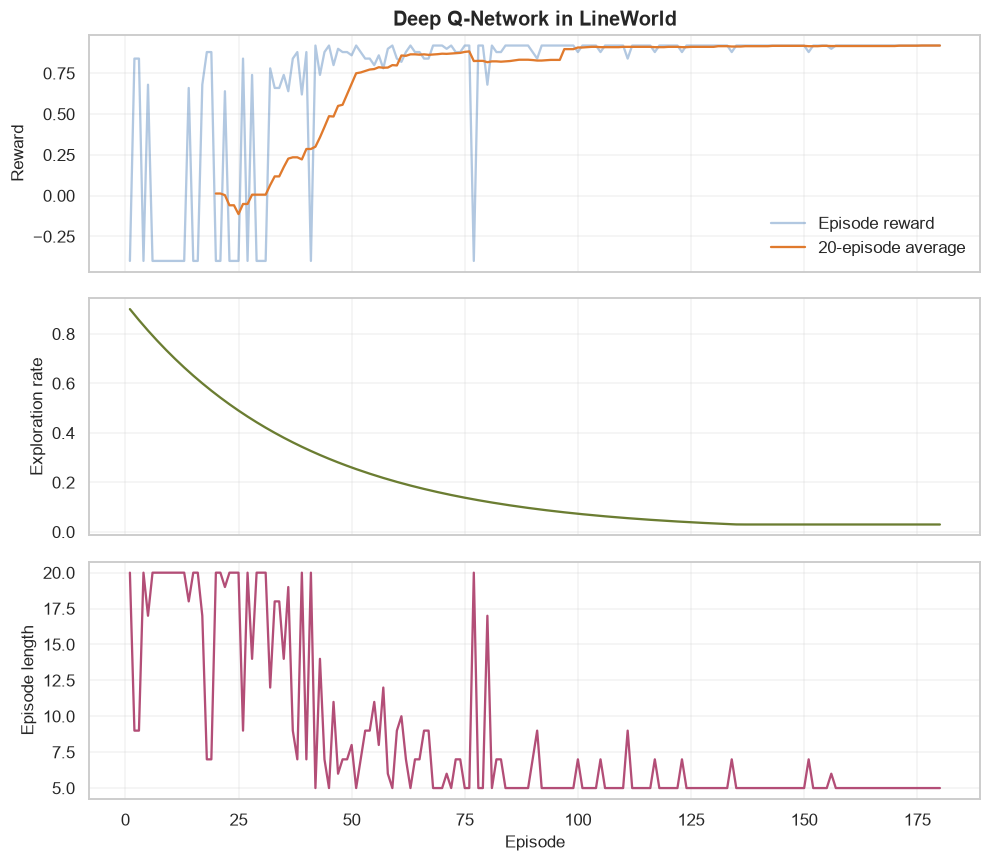

In [3]:
class LineWorld:
    def __init__(self, length=6, max_steps=20):
        self.length=length
        self.max_steps=max_steps
    def reset(self):
        self.state=0
        self.steps=0
        return self.state
    def step(self, action):
        self.steps+=1
        self.state=int(np.clip(self.state + (-1 if action==0 else 1),0,self.length-1))
        terminated=self.state==self.length-1
        truncated=self.steps>=self.max_steps
        reward=1.0 if terminated else -0.02
        return self.state,reward,terminated,truncated

import torch
from torch import nn
torch.set_num_threads(1)
environment=LineWorld()
model=nn.Sequential(nn.Linear(environment.length,16),nn.ReLU(),nn.Linear(16,2))
target_model=nn.Sequential(nn.Linear(environment.length,16),nn.ReLU(),nn.Linear(16,2))
target_model.load_state_dict(model.state_dict())
optimizer=torch.optim.Adam(model.parameters(),lr=.01); loss_fn=nn.SmoothL1Loss()
replay=[]; rewards=[]; exploration_rates=[]; lengths=[]

def encode(state):
    result=np.zeros(environment.length,dtype="float32"); result[state]=1; return result

for episode in range(180):
    state=environment.reset(); epsilon=max(.03,.9*(.975**episode)); total=0.0
    for step in range(environment.max_steps):
        with torch.no_grad(): q_values=model(torch.tensor(encode(state)))
        action=int(rng.integers(2)) if rng.random()<epsilon else int(torch.argmax(q_values))
        next_state,reward,terminated,truncated=environment.step(action)
        replay.append((state,action,reward,next_state,terminated))
        replay=replay[-500:]
        if len(replay)>=24:
            indices=rng.choice(len(replay),24,replace=False); batch=[replay[index] for index in indices]
            states=torch.tensor(np.stack([encode(item[0]) for item in batch]))
            actions=torch.tensor([item[1] for item in batch],dtype=torch.long)
            batch_rewards=torch.tensor([item[2] for item in batch],dtype=torch.float32)
            next_states=torch.tensor(np.stack([encode(item[3]) for item in batch]))
            terminals=torch.tensor([item[4] for item in batch],dtype=torch.float32)
            chosen=model(states).gather(1,actions[:,None]).squeeze()
            with torch.no_grad(): targets=batch_rewards+.95*(1-terminals)*target_model(next_states).max(1).values
            loss=loss_fn(chosen,targets); optimizer.zero_grad(); loss.backward(); optimizer.step()
        state=next_state; total+=reward
        if terminated or truncated: break
    if episode%15==0: target_model.load_state_dict(model.state_dict())
    rewards.append(total); exploration_rates.append(epsilon); lengths.append(step+1)
with torch.no_grad(): learned_q=model(torch.eye(environment.length)).numpy()
print("Input/hidden/output:",(environment.length,environment.length),(environment.length,16),learned_q.shape)
print("Parameters:",sum(p.numel() for p in model.parameters()),"final Q-values:\n",learned_q.round(2))
plot_rl_metrics(rewards,exploration_rates,lengths,"Deep Q-Network in LineWorld")

**How to interpret the result:** The network assigns increasingly large values to rightward actions near the goal; learning curves show improved reward and shorter paths.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Replay capacity changes experience diversity and memory usage; large buffers can also retain obsolete behavior.

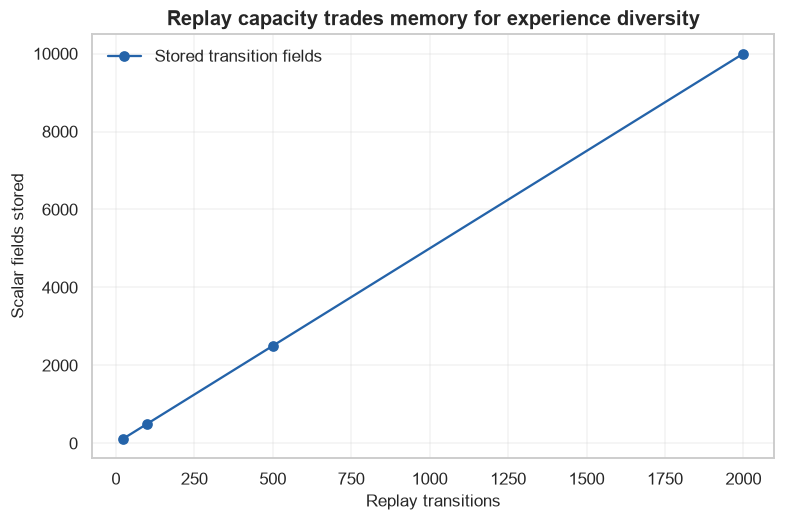

In [4]:
buffer_sizes=[24,100,500,2000]
memory_items=np.array(buffer_sizes)*5
figure,axis=plt.subplots(); axis.plot(buffer_sizes,memory_items,marker="o",color=COURSE_COLORS["blue"],label="Stored transition fields")
axis.set(title="Replay capacity trades memory for experience diversity",xlabel="Replay transitions",ylabel="Scalar fields stored"); axis.legend(); plt.show()

## 18. Common mistakes

            - Treating reward as a supervised label
- Evaluating while exploration is still active
- Comparing agents with different random seeds or episode limits
- Ignoring truncation versus true termination

            ## 19. Advantages and disadvantages

            **Advantages**

            - Directly optimizes sequential behavior
- Can learn from interaction without action labels

            **Disadvantages**

            - Experience can be expensive or unsafe
- Results are noisy and sensitive to reward design

            ## 20. When to use and when not to use the algorithm

            **Use it when:** actions influence future states and the objective is naturally expressed through cumulative reward.

            **Do not use it when:** a static labeled prediction problem is sufficient or unsafe exploration cannot be controlled.

## 21. Exercises

1. **Conceptual:** Why is RL not supervised learning?
2. **Mathematical/hand calculation:** Calculate return for rewards [2,0,4] with gamma=.5.
3. **Coding/experimentation:** Change one hyperparameter and compare learning across at least three seeds.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. The agent is not given correct actions; it receives consequences and must handle delayed credit.
2. 2+.5(0)+.25(4)=3.
3. Keep all other settings fixed, plot each seed plus aggregate mean, and avoid selecting only the best run.

</details>

## 23. Summary and key takeaways

            - The policy maps states to action choices
- Return assigns credit across time
- Exploration gathers information while exploitation uses current knowledge
- Learning curves require repeated, controlled evaluation

            ## 24. Further reading

            - [Gymnasium documentation](https://gymnasium.farama.org/)
- [Sutton and Barto: Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html)